# Step 2b. KRX 정규장 일봉 검증 (v2)

Step 2(`03_quality.ipynb`)에서 기존 DB 일봉(`stock_daily_candles`)이 NXT 출범(2025-03-04) 이후 KRX+NXT 통합 시세로 보인다는 문제를 찾았다. 그래서 KRX 정규장 일봉(`krx_daily_candles`)을 새로 받았다. 이 노트북은 새 데이터를 검증하고, 수급 데이터의 기준(KRX 단독인지, 통합인지)을 확인한다.

- 범위: 2024-01-02 ~ 2026-06-30(학습 구간). 검증 구간 이후는 읽지 않는다.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.data import load_table
from src.target import flag_low_spikes
from src.features import flag_high_spikes
from src import plotting as P

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
P.setup()
S, E, NXT = "2024-01-01", "2026-06-30", "2025-03-04"

k = load_table("krx_daily_candles", S, E).sort_values(["symbol", "trade_date"]).reset_index(drop=True)
o = load_table("stock_daily_candles", S, E).sort_values(["symbol", "trade_date"]).reset_index(drop=True)
print(f"KRX {len(k):,}행, {k.symbol.nunique()}종목, {k.trade_date.nunique()}거래일 | 기존 {len(o):,}행, {o.symbol.nunique()}종목")
print("거래일 캘린더 차이:", len(pd.Index(k.trade_date.unique()).symmetric_difference(pd.Index(o.trade_date.unique()))))

KRX 137,632행, 231종목, 606거래일 | 기존 137,269행, 229종목
거래일 캘린더 차이: 0


## 1. 기본 점검

In [2]:
PR = ["open_price", "high_price", "low_price", "close_price"]
pd.Series({
    "중복 (종목, 일자)": int(k.duplicated(["symbol", "trade_date"]).sum()),
    "NULL (가격·거래량)": int(k[PR + ["volume"]].isna().sum().sum()),
    "가격 0 이하": int((k[PR] <= 0).any(axis=1).sum()),
    "High < Low": int((k.high_price < k.low_price).sum()),
    "High < max(O,C)": int((k.high_price < k[["open_price", "close_price"]].max(axis=1)).sum()),
    "Low > min(O,C)": int((k.low_price > k[["open_price", "close_price"]].min(axis=1)).sum()),
    "거래정지 행 (halted=1)": int(k.halted.sum()),
    "거래정지 행 중 O=H=L=C": int((k.halted.eq(1) & k[PR].nunique(axis=1).eq(1)).sum()),
    "상장주식수 NULL": int(k.listed_shares.isna().sum()),
}).to_frame("값")

,값
"중복 (종목, 일자)",0
NULL (가격·거래량),0
가격 0 이하,0
High < Low,0
"High < max(O,C)",0
"Low > min(O,C)",0
거래정지 행 (halted=1),482
거래정지 행 중 O=H=L=C,482
상장주식수 NULL,0


In [3]:
# 폐지·합병 3종목과 코스닥 이전 2종목의 기간
k.groupby("symbol").trade_date.agg(["min", "max", "size"]).loc[["003410", "010620", "042670", "034230", "066970"]]

,min,max,size
symbol,,,
003410,2024-01-02,2024-07-08,127
010620,2024-01-02,2025-12-12,475
042670,2024-01-02,2026-01-23,502
034230,2024-06-24,2026-06-30,490
066970,2024-01-29,2026-06-30,587


## 2. 기존 DB 일봉과 비교

In [4]:
m = k.merge(o, on=["symbol", "trade_date"], suffixes=("_k", "_o"))
m["기간"] = np.where(m.trade_date < NXT, "NXT 이전", "NXT 이후")
rows = []
for col in PR:
    rel = (m[f"{col}_k"] / m[f"{col}_o"] - 1).abs()
    for p_, g in m.groupby("기간"):
        rows.append({"컬럼": col, "기간": p_, "최대 차이": rel[g.index].max(), "0.1% 넘게 다른 비율": (rel[g.index] > 0.001).mean()})
vr = m.volume_o / m.volume_k.replace(0, np.nan)
for p_, g in m.groupby("기간"):
    rows.append({"컬럼": "volume (기존/KRX)", "기간": p_, "최대 차이": np.nan, "0.1% 넘게 다른 비율": ((vr[g.index] - 1).abs() > 0.001).mean(),
                 "비율 중앙값": vr[g.index].median()})
pd.DataFrame(rows).round(4)

,컬럼,기간,최대 차이,0.1% 넘게 다른 비율,비율 중앙값
0,open_price,NXT 이전,0.0003,0.0000,NaN
1,open_price,NXT 이후,0.4578,0.7691,NaN
2,high_price,NXT 이전,0.0003,0.0000,NaN
3,high_price,NXT 이후,0.2386,0.3228,NaN
4,low_price,NXT 이전,0.0003,0.0000,NaN
5,low_price,NXT 이후,0.4319,0.2403,NaN
6,close_price,NXT 이전,0.0003,0.0000,NaN
7,close_price,NXT 이후,0.2350,0.7119,NaN
8,volume (기존/KRX),NXT 이전,NaN,0.0000,1.0000
9,volume (기존/KRX),NXT 이후,NaN,0.8453,1.3118


## 3. 비정상 꼬리(스파이크)와 가격제한폭

In [5]:
def spikes(c):
    c = c.sort_values(["symbol", "trade_date"]).reset_index(drop=True)
    return c.assign(lo=flag_low_spikes(c), hi=flag_high_spikes(c), nxt=c.trade_date >= NXT)

ks, os_ = spikes(k), spikes(o)
tab = pd.DataFrame({
    "기존 저가 스파이크": os_.groupby("nxt").lo.sum(), "KRX 저가 스파이크": ks.groupby("nxt").lo.sum(),
    "기존 고가 스파이크": os_.groupby("nxt").hi.sum(), "KRX 고가 스파이크": ks.groupby("nxt").hi.sum(),
}).rename(index={False: "NXT 이전", True: "NXT 이후"})
display(tab)
ks["prev"] = ks.groupby("symbol").close_price.shift()
ks["r"] = ks.close_price / ks.prev - 1
raw_r = ks.groupby("symbol").raw_close.pct_change()
print(f"수정주가 종가 |수익률| > 30.5%: {int((ks.r.abs() > 0.305).sum())}건, 원주가 기준: {int((raw_r.abs() > 0.305).sum())}건(기업 이벤트일)")
print("KRX에 남은 저가 스파이크:")
display(ks[ks.lo][["symbol", "trade_date", "prev", "open_price", "high_price", "low_price", "close_price", "volume"]])

,기존 저가 스파이크,KRX 저가 스파이크,기존 고가 스파이크,KRX 고가 스파이크
nxt,,,,
NXT 이전,1,1,15,14
NXT 이후,90,2,105,16


수정주가 종가 |수익률| > 30.5%: 0건, 원주가 기준: 7건(기업 이벤트일)
KRX에 남은 저가 스파이크:


,symbol,trade_date,prev,open_price,high_price,low_price,close_price,volume
16508,003030,2024-08-05,172600.0,174000.0,195800.0,143100.0,174900.0,17654.0
32817,006110,2026-05-12,79300.0,79300.0,85400.0,66000.0,79300.0,440302.0
118744,268280,2025-12-08,138700.0,141900.0,141900.0,115500.0,138200.0,972.0


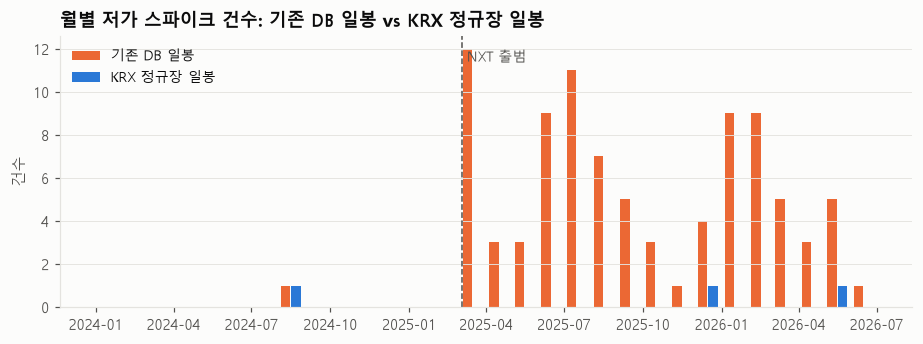

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.2))
mo = os_.assign(ym=os_.trade_date.dt.to_period("M").dt.to_timestamp()).groupby("ym").lo.sum()
mk = ks.assign(ym=ks.trade_date.dt.to_period("M").dt.to_timestamp()).groupby("ym").lo.sum()
x = mo.index + pd.Timedelta(days=15)
ax.bar(x - pd.Timedelta(days=6), mo.values, width=11, color=P.SERIES[1], label="기존 DB 일봉")
ax.bar(x + pd.Timedelta(days=6), mk.reindex(mo.index, fill_value=0).values, width=11, color=P.SERIES[0], label="KRX 정규장 일봉")
ax.axvline(pd.Timestamp(NXT), color=P.TEXT_2, lw=1, ls="--")
ax.text(pd.Timestamp(NXT), ax.get_ylim()[1] * 0.95, " NXT 출범", color=P.TEXT_2, fontsize=9, va="top")
ax.set_title("월별 저가 스파이크 건수: 기존 DB 일봉 vs KRX 정규장 일봉")
ax.set_ylabel("건수")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.grid(axis="x", visible=False)
P.save(fig, "03b_krx_spikes")
plt.show()

## 4. 수급 데이터의 기준 (KRX 단독인가, KRX+NXT 통합인가)

수급 변수는 거래량으로 나눠 만든다. 분자(수급)와 분모(거래량)의 기준이 다르면, NXT 이후 값이 체계적으로 부풀려진다.

In [7]:
b = o[["symbol", "trade_date", "volume"]].rename(columns={"volume": "vol_all"}).merge(
    k[["symbol", "trade_date", "volume"]].rename(columns={"volume": "vol_krx"}), on=["symbol", "trade_date"])
b["기간"] = np.where(b.trade_date < NXT, "NXT 이전", "NXT 이후")
inv = load_table("stock_investor_trading", S, E)
grp = ["individual", "foreigner", "institution", "other_corp"]
inv["buy_sum"] = inv[[f"{g_}_buy_volume" for g_ in grp]].sum(axis=1)
x = inv.merge(b, on=["symbol", "trade_date"])
x = x[x.vol_krx > 0]
res = x.groupby("기간").apply(lambda g: pd.Series({"투자자별 매수 합 / KRX 거래량": (g.buy_sum / g.vol_krx).median(),
                                                   "투자자별 매수 합 / 기존(통합) 거래량": (g.buy_sum / g.vol_all).median()}))
ss = load_table("stock_short_selling", S, E).merge(b, on=["symbol", "trade_date"])
ss = ss[(ss.vol_krx > 0) & ss.short_volume_rate.notna() & (ss.trade_date >= "2025-03-31")]
pg = load_table("stock_program_trades", S, E).merge(b, on=["symbol", "trade_date"])
pg["buy"] = pg.arbitrage_buy_volume + pg.non_arbitrage_buy_volume
display(res.round(4))
print("공매도 비율 컬럼과의 차이(중앙값): short/KRX 거래량", round(float((ss.short_volume_rate - ss.short_volume / ss.vol_krx).abs().median()), 6),
      "| short/통합 거래량", round(float((ss.short_volume_rate - ss.short_volume / ss.vol_all).abs().median()), 6))
print("프로그램 매수 > KRX 거래량인 행 비율:", round(float((pg.buy > pg.vol_krx * 1.0001).mean()), 5))

,투자자별 매수 합 / KRX 거래량,투자자별 매수 합 / 기존(통합) 거래량
기간,,
NXT 이전,0.9993,0.9993
NXT 이후,1.3470,0.9991


공매도 비율 컬럼과의 차이(중앙값): short/KRX 거래량 3e-06 | short/통합 거래량 0.01774
프로그램 매수 > KRX 거래량인 행 비율: 4e-05


## 5. 결론

- **KRX 일봉은 믿을 수 있다.**
  - NXT 이전 구간은 기존 일봉과 가격 차이가 최대 0.035%이고, 거래량이 같다(수정주가 반올림 차이만 있다).
  - 기본 점검(중복, NULL, OHLC 논리 위반) 결과는 모두 0건이다.
  - 수정 후 하루 수익률이 ±30.5%를 넘는 곳이 없다.
- **비정상 꼬리가 사라졌다.** NXT 이후 저가 스파이크는 90건에서 2건으로, 고가 스파이크는 105건에서 16건으로 줄었다. 남은 건수는 NXT 이전(저가 1건, 고가 14건)과 비슷해서 실제 가격 움직임으로 본다. **스파이크 보정은 더 이상 쓰지 않는다**(`clean=False`).
- **기존 일봉은 NXT 이후 KRX+NXT 통합 시세였다.** 거래량이 KRX보다 중앙값 1.31배 많다. Step 2의 가설이 확인됐다.
- **수급 데이터의 기준**
  - 투자자별 매매(그리고 같은 원천인 기관 세부 매매)는 **통합 기준**이다. NXT 이후 매수 합을 KRX 거래량으로 나누면 1.35배가 되고, 통합 거래량으로 나누면 1.0에 가깝다.
  - 공매도는 **KRX 기준**이다. 공매도 비율 컬럼이 "공매도 수량 ÷ KRX 거래량"과 정확히 같다.
  - 프로그램 매매도 KRX 거래량을 넘지 않아 KRX 기준으로 본다.
  - → 수급 변수의 분모를 기준에 맞춰 나눈다(`src/features.py` `flow_features`의 `vol_all` 인자).
- **남은 한계**
  - KRX 거래량·거래대금에 시간외 거래가 포함됐는지는 확인할 수 없다(가격은 정규장 값). 다만 NXT 이전 구간에서 투자자별 합계와 거래량이 일치하므로, 수급 데이터와 포함 범위는 같다.
  - 폐지·합병 3종목은 기존 DB에 수급 데이터가 없어서, 수급 변수만 비어 있다(표본의 0.9%).